In [1]:
from pathlib import Path
import soundfile as sf
from IPython.display import Audio, display
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
DATA_DIR = Path("datasets/ssw/data")
ANN_PATH = Path("datasets/ssw/annotations.csv")
OUT_DIR = Path("datasets/ssw_clips")
N_SAMPLES_PER_CLASS = 20
CLIP_SEC = 5.0

TARGET_CLASSES = {"cangoo", "pilwoo", "bkcchi"}
BIRD_CLASS = "Species eBird Code"


In [3]:
ann = pd.read_csv(ANN_PATH)
ann[BIRD_CLASS].unique()

<StringArray>
[ 'cangoo',    '????',  'blujay',  'killde',  'amecro',  'eursta',  'rewbla',
  'whbnut',  'haiwoo',  'amerob',  'amegfi',  'dowwoo',  'comrav',  'norcar',
  'comgra', 'mallar3',  'rebwoo',  'tuftit',  'bkcchi',  'pilwoo',  'snogoo',
  'tunswa',  'sonspa',  'moudov',  'bnhcow',  'wooduc',  'amewoo',  'brncre',
  'easpho',  'ribgul',  'gockin',  'rusbla',  'swaspa',  'norfli',  'yebsap',
  'houfin',  'ruckin',  'bcnher', 'belkin1',  'treswa',  'norwat',  'comyel',
  'grcfly',  'whtspa',  'eastow', 'ovenbi1',  'purfin',  'grycat',   'veery',
  'woothr',  'buhvir',  'scatan',  'boboli',  'solsan',  'bkbwar',  'balori',
  'yelwar', 'grbher3',  'yerwar',  'herthr',  'amered',  'naswar',  'btnwar',
 'reevir1',  'buwwar',  'chswar',  'warvir',  'robgro',  'pinsis',  'coohaw',
  'eawpew',  'aldfly',  'rebnut',  'cedwax',  'brdowl',  'easkin',  'redcro',
  'daejun',  'yetvir',  'easblu',  'houwre',  'hoowar']
Length: 82, dtype: str

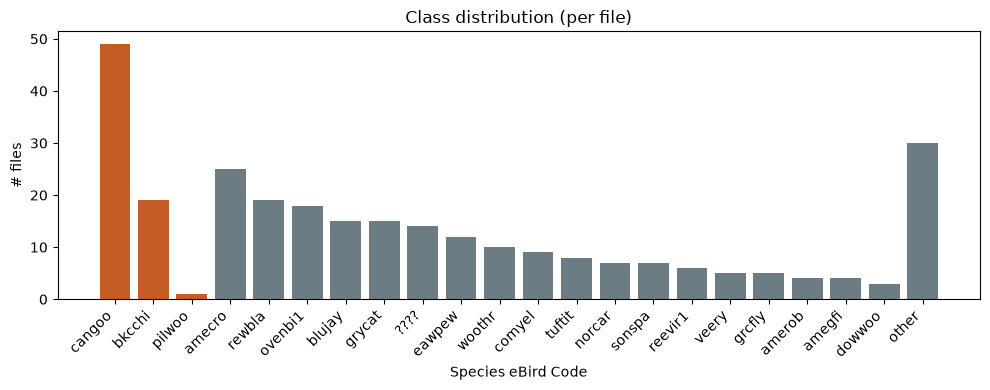

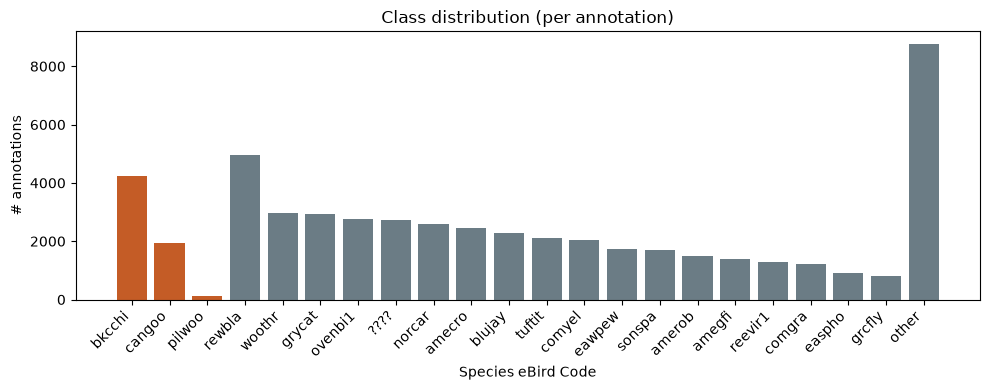

In [4]:
def _histogram_counts_with_targets(counts, top_n: int = 20):
    """Keep top_n classes, force-include TARGET_CLASSES, bucket the rest as other."""
    keep = set(counts.head(top_n).index) | set(TARGET_CLASSES)
    top = counts[counts.index.isin(keep)].copy()
    other = counts[~counts.index.isin(keep)].sum()
    if other:
        top["other"] = other
    # targets first (by count), then other classes, then other bucket
    target_part = top[top.index.isin(TARGET_CLASSES)].sort_values(ascending=False)
    rest_part = top[~top.index.isin(TARGET_CLASSES) & (top.index != "other")].sort_values(ascending=False)
    parts = [target_part, rest_part]
    if "other" in top.index:
        parts.append(top.loc[["other"]])
    return pd.concat(parts)


def _bar_colors(labels):
    target_color = "#c45c26"
    other_color = "#6b7c85"
    return [target_color if lab in TARGET_CLASSES else other_color for lab in labels]


def display_class_histogram_per_filename(top_n: int = 20):
    """One vote per file (dominant class). TARGET_CLASSES always shown, highlighted."""
    file_label = (
        ann.groupby("Filename")[BIRD_CLASS].agg(lambda s: s.value_counts().index[0])
    )
    counts = file_label.value_counts()
    top = _histogram_counts_with_targets(counts, top_n=top_n)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(top.index.astype(str), top.values, color=_bar_colors(top.index))
    ax.set_xlabel(BIRD_CLASS)
    ax.set_ylabel("# files")
    ax.set_title("Class distribution (per file)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def display_class_histogram_per_annotation(top_n: int = 20):
    """One vote per time annotation. TARGET_CLASSES always shown, highlighted."""
    counts = ann[BIRD_CLASS].value_counts()
    top = _histogram_counts_with_targets(counts, top_n=top_n)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(top.index.astype(str), top.values, color=_bar_colors(top.index))
    ax.set_xlabel(BIRD_CLASS)
    ax.set_ylabel("# annotations")
    ax.set_title("Class distribution (per annotation)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


display_class_histogram_per_filename()
display_class_histogram_per_annotation()


In [5]:
# how many annotations per class

for b_class in sorted(TARGET_CLASSES):
    n = (ann[BIRD_CLASS] == b_class).sum()
    print(f"{b_class}: {n}")

bkcchi: 4235
cangoo: 1946
pilwoo: 127


In [6]:
# how many annotations per class with given duration

dur = ann["End Time (s)"] - ann["Start Time (s)"]
mask = ann[BIRD_CLASS].isin(TARGET_CLASSES) & (dur >= 5.0)
print("Total target annotations ≥5s:", mask.sum())
print(
    ann.loc[mask, BIRD_CLASS]
    .value_counts()
    .reindex(sorted(TARGET_CLASSES), fill_value=0)
)

Total target annotations ≥5s: 1800
Species eBird Code
bkcchi    874
cangoo    906
pilwoo     20
Name: count, dtype: int64


In [7]:
# candidates: target classes, long enough for CLIP_SEC
candidates = ann.loc[ann[BIRD_CLASS].isin(TARGET_CLASSES)].copy()
candidates["duration"] = candidates["End Time (s)"] - candidates["Start Time (s)"]
candidates = candidates[candidates["duration"] >= CLIP_SEC].reset_index(drop=True)

print("Candidates (>= CLIP_SEC) per class:")
print(
    candidates[BIRD_CLASS]
    .value_counts()
    .reindex(sorted(TARGET_CLASSES), fill_value=0)
)


Candidates (>= CLIP_SEC) per class:
Species eBird Code
bkcchi    874
cangoo    906
pilwoo     20
Name: count, dtype: int64


In [8]:
def build_intervals_by_file(annotations: pd.DataFrame) -> dict[str, list[tuple[float, float]]]:
    """All annotation intervals per file, sorted by start (any class)."""
    sorted_ann = annotations.sort_values(["Filename", "Start Time (s)"])
    by_file: dict[str, list[tuple[float, float]]] = {}
    for filename, group in sorted_ann.groupby("Filename", sort=False):
        by_file[filename] = list(
            zip(group["Start Time (s)"].to_numpy(), group["End Time (s)"].to_numpy())
        )
    return by_file


def pick_noise_for_interval(
    start: float,
    end: float,
    all_intervals: list[tuple[float, float]],
    file_duration_sec: float,
    clip_sec: float = 5.0,
    noise_target_gap: float = 1.0,
) -> tuple[float, float, float, float] | None:
    """
    For a chosen signal interval, pick a same-file noise window of clip_sec
    immediately before or after it (with gap), not overlapping other annotations.
    Returns (sig0, sig1, noise0, noise1) or None.
    """
    prev_end = 0.0
    next_start = file_duration_sec
    for s, e in all_intervals:
        if e <= start:
            prev_end = max(prev_end, e)
        elif s >= end:
            next_start = s
            break

    sig0, sig1 = start, start + clip_sec

    if start - prev_end >= clip_sec + noise_target_gap:
        noise0 = start - clip_sec - noise_target_gap
        noise1 = start - noise_target_gap
        return sig0, sig1, noise0, noise1

    if next_start - end >= clip_sec + noise_target_gap:
        noise0 = end + noise_target_gap
        noise1 = end + clip_sec + noise_target_gap
        return sig0, sig1, noise0, noise1

    return None


def sample_rows_per_class(
    pool: pd.DataFrame,
    n_per_class: int,
    bird_class_col: str,
    classes: set[str],
    seed: int = 0,
) -> pd.DataFrame:
    """Prefer one annotation per file, then sample n_per_class per class."""
    selected_rows = []
    for cls in sorted(classes):
        cls_pool = pool[pool[bird_class_col] == cls]
        if cls_pool.empty:
            print(f"Warning: no candidates for {cls}")
            continue
        one_per_file = cls_pool.groupby("Filename", group_keys=False).sample(
            n=1, random_state=seed
        )
        if len(one_per_file) >= n_per_class:
            chosen = one_per_file.sample(n=n_per_class, random_state=seed)
        else:
            chosen = cls_pool.sample(
                n=min(n_per_class, len(cls_pool)),
                random_state=seed,
            )
            if len(chosen) < n_per_class:
                print(f"Warning: only {len(chosen)}/{n_per_class} candidates for {cls}")
        selected_rows.append(chosen)
    if not selected_rows:
        return pool.iloc[0:0].copy()
    return pd.concat(selected_rows, ignore_index=True)


def read_and_save_slice(in_path, t0, t1, out_path: Path):
    info = sf.info(in_path)
    sr = info.samplerate
    start = int(t0 * sr)
    frames = int((t1 - t0) * sr)
    audio, _ = sf.read(in_path, start=start, frames=frames, dtype="float32")
    sf.write(out_path, audio, sr)


In [9]:
intervals_by_file = build_intervals_by_file(ann)
selected = sample_rows_per_class(
    candidates,
    n_per_class=N_SAMPLES_PER_CLASS,
    bird_class_col=BIRD_CLASS,
    classes=TARGET_CLASSES,
    seed=0,
)
print(selected.groupby(BIRD_CLASS).size().reindex(sorted(TARGET_CLASSES), fill_value=0))
selected.head()


Species eBird Code
bkcchi    20
cangoo    20
pilwoo    20
dtype: int64


,Filename,Start Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Species eBird Code,duration
0,SSW_015_20170225_200022Z.flac,2605.3,2627.8,1274,9803,bkcchi,22.5
1,SSW_074_20170401_160011Z.flac,1855.0,1906.2,3125,7890,bkcchi,51.2
2,SSW_230_20170708_000000Z.flac,1340.6,1351.8,5873,7698,bkcchi,11.2
3,SSW_170_20170603_120008Z.flac,2629.7,2639.1,827,9699,bkcchi,9.4
4,SSW_190_20170610_140010Z.flac,2615.1,2636.9,2307,5244,bkcchi,21.8


In [10]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

saved_by_class = {c: 0 for c in TARGET_CLASSES}
used_keys: set[tuple] = set()


def row_key(row) -> tuple:
    return (row["Filename"], float(row["Start Time (s)"]), float(row["End Time (s)"]))


# Prefer the diverse `selected` rows first, then remaining candidates for that class.
for target_class in sorted(TARGET_CLASSES):
    preferred = selected[selected[BIRD_CLASS] == target_class]
    preferred_keys = {row_key(r) for _, r in preferred.iterrows()}
    rest = candidates[candidates[BIRD_CLASS] == target_class].copy()
    rest = rest[~rest.apply(lambda r: row_key(r) in preferred_keys, axis=1)]
    rest = rest.sample(frac=1, random_state=0) if len(rest) else rest
    queue = pd.concat([preferred, rest], ignore_index=True)

    for _, row in queue.iterrows():
        if saved_by_class[target_class] >= N_SAMPLES_PER_CLASS:
            break

        key = row_key(row)
        if key in used_keys:
            continue

        path_audio = DATA_DIR / row["Filename"]
        if not path_audio.exists():
            print(f"Skip missing file {path_audio.name}")
            continue

        picked = pick_noise_for_interval(
            start=float(row["Start Time (s)"]),
            end=float(row["End Time (s)"]),
            all_intervals=intervals_by_file.get(row["Filename"], []),
            file_duration_sec=sf.info(path_audio).duration,
            clip_sec=CLIP_SEC,
        )
        if picked is None:
            continue

        sig0, sig1, noise0, noise1 = picked
        used_keys.add(key)
        idx = saved_by_class[target_class]
        stem = path_audio.stem
        # matched pair from the same file, shared stem + class + index
        sig_out = OUT_DIR / f"{stem}_{target_class}_{idx:02d}_signal.flac"
        noise_out = OUT_DIR / f"{stem}_{target_class}_{idx:02d}_noise.flac"
        read_and_save_slice(path_audio, sig0, sig1, sig_out)
        read_and_save_slice(path_audio, noise0, noise1, noise_out)
        saved_by_class[target_class] += 1
        print(
            f"Saved {target_class}[{idx}] {path_audio.name} "
            f"sig={sig0:.1f}-{sig1:.1f} noise={noise0:.1f}-{noise1:.1f}"
        )

print("\nSaved per class:", saved_by_class)
for cls, n in saved_by_class.items():
    if n < N_SAMPLES_PER_CLASS:
        print(f"Warning: {target_class} only got {n}/{N_SAMPLES_PER_CLASS} matched pairs")


Saved bkcchi[0] SSW_015_20170225_200022Z.flac sig=2605.3-2610.3 noise=2599.3-2604.3
Saved bkcchi[1] SSW_190_20170610_140010Z.flac sig=2615.1-2620.1 noise=2637.9-2642.9
Saved bkcchi[2] SSW_268_20170819_110011Z.flac sig=1561.7-1566.7 noise=1579.1-1584.1
Saved bkcchi[3] SSW_176_20170603_180013Z.flac sig=3075.8-3080.8 noise=3069.8-3074.8
Saved bkcchi[4] SSW_058_20170325_110008Z.flac sig=3438.0-3443.0 noise=3506.0-3511.0
Saved bkcchi[5] SSW_113_20170429_160010Z.flac sig=1840.4-1845.4 noise=1834.4-1839.4
Saved bkcchi[6] SSW_060_20170325_140009Z.flac sig=504.9-509.9 noise=498.9-503.9
Saved bkcchi[7] SSW_197_20170610_210015Z.flac sig=1469.2-1474.2 noise=1463.2-1468.2
Saved bkcchi[8] SSW_227_20170701_200015Z.flac sig=1619.3-1624.3 noise=1613.3-1618.3
Saved bkcchi[9] SSW_264_20170805_190017Z.flac sig=2588.1-2593.1 noise=2582.1-2587.1
Saved bkcchi[10] SSW_188_20170610_120008Z.flac sig=118.3-123.3 noise=125.9-130.9
Saved bkcchi[11] SSW_252_20170722_150014Z.flac sig=123.0-128.0 noise=117.0-122.0
Sa

In [11]:
# listen to one matched pair (edit path after extract)
pairs = sorted(OUT_DIR.glob("*_signal.flac"))
if not pairs:
    print("No signal clips yet — run the extract cell first.")
else:
    sig_path = pairs[0]
    noise_path = Path(str(sig_path).replace("_signal.flac", "_noise.flac"))
    print(sig_path.name, "<->", noise_path.name)
    audio, sr = sf.read(sig_path)
    display(Audio(audio, rate=sr))
    audio, sr = sf.read(noise_path)
    display(Audio(audio, rate=sr))


SSW_003_20170225_030002Z_cangoo_02_signal.flac <-> SSW_003_20170225_030002Z_cangoo_02_noise.flac
